# Top 100 Investable Stocks Analysis - 2025

## Overview

This notebook identifies the top 100 investable US stocks for 2025 using a liquidity-aware ranking methodology. The analysis combines return performance with liquidity metrics to ensure practical investability.

## Key Features

- **Universe**: Official SEC ticker list (common stocks with tickers <= 4 characters)
- **Price Filter**: Minimum $1.00 end-of-year price (survival filter)
- **Liquidity Filter**: Minimum $500K average daily dollar volume
- **Ranking**: Composite score (70% return, 30% liquidity)
- **Time Windows**: Bookend approach to handle data gaps reliably


In [1]:
# --- Import Libraries ---
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import time
import logging
import os
import matplotlib.cm as cm
from tqdm import tqdm
from datetime import datetime, timedelta

logging.getLogger('yfinance').setLevel(logging.CRITICAL)

# --- Configuration ---
# Defining the "Bookend" windows to capture year-end prices reliably
START_WINDOW = ("2024-12-20", "2025-01-05")
END_WINDOW   = ("2025-12-20", "2026-01-05")

# API Safety Thresholds
CHUNK_SIZE = 50      
PAUSE_SEC = 4.0      

# Investment Strategy Parameters
DATA_GLITCH_FILTER = 0.011  # Removes math artifacts (e.g. prices near zero)
THRESH_PRICE = 1.00         # The 'Buck Rule': Minimum price for investable assets
LIQUIDITY_TOP_N = 200       # Only check volume for the top N performers (the "Fast Way")
MIN_LIQUIDITY_USD = 500_000 # Minimum $500k/day average volume for retail safety

# Checkpoint File Path
CHECKPOINT_FILE = "market_universe_checkpoint.csv"

SEC_HEADERS = {'User-Agent': "DataScientist (datascientist@example.com)"}

# --- Helper Functions ---

def _looks_like_etf_by_name(company_name):
    """KISS heuristic to catch ETFs/Funds early without extra API calls."""
    if not isinstance(company_name, str): return False
    s = company_name.upper()
    keywords = [" ETF", "ETFS", "ETN", "FUND", "TRUST", "ISHARES", "VANGUARD", "SPDR", "INDEX"]
    return any(k in s for k in keywords)

def get_usa_tickers():
    """Fetches official SEC list and filters out ETFs/Funds immediately."""
    print("=" * 70)
    print("🎯 STARTING OPTIMIZED MARKET ANALYSIS")
    print("=" * 70)
    print("🇺🇸 Fetching official ticker list from SEC...")
    url = "https://www.sec.gov/files/company_tickers.json"
    try:
        response = requests.get(url, headers=SEC_HEADERS)
        df = pd.DataFrame.from_dict(response.json(), orient='index')
        df = df.rename(columns={'ticker': 'Symbol', 'title': 'Company Name'})
        
        # Optimization: Filter out ETFs and non-common stocks immediately
        df = df[~df['Company Name'].apply(_looks_like_etf_by_name)]
        filtered_df = df[df['Symbol'].str.len() <= 4].copy()
        
        print(f"✅ SEC universe loaded: {len(filtered_df)} potential common stocks (ETFs filtered).")
        return filtered_df
    except Exception as e:
        print(f"❌ SEC Fetch failed: {e}")
        return pd.DataFrame()

def batch_download_prices(tickers, start, end, label):
    """Downloads adjusted close prices in small chunks."""
    print("-" * 70)
    print(f"📡 {label}: Probing {len(tickers)} tickers...")
    results = []
    total_batches = (len(tickers) // CHUNK_SIZE) + 1
    
    for i in range(0, len(tickers), CHUNK_SIZE):
        chunk = tickers[i : i + CHUNK_SIZE]
        current_batch = (i // CHUNK_SIZE) + 1
        try:
            data = yf.download(chunk, start=start, end=end, progress=False, threads=1, auto_adjust=True)['Close']
            if isinstance(data, pd.Series): data = data.to_frame(name=chunk[0])
            if not data.empty: results.append(data)
            
            if current_batch % 20 == 0 or current_batch == total_batches:
                print(f"   ✓ Progress: Batch {current_batch}/{total_batches} processed...")
            time.sleep(PAUSE_SEC)
        except Exception:
            time.sleep(PAUSE_SEC * 2)
            
    if not results: return pd.Series(dtype=float)
    full_df = pd.concat(results, axis=1)
    return full_df.ffill().iloc[-1]

# --- Main Logic ---

def process_market(ticker_df):
    """Survival Filter -> Start Price Filter -> IPO Discovery -> 70/30 Ranking"""
    
    # Check for Intermediary Checkpoint to save time
    if os.path.exists(CHECKPOINT_FILE):
        print(f"📂 Found existing checkpoint: {CHECKPOINT_FILE}. Skipping download...")
        raw_df = pd.read_csv(CHECKPOINT_FILE)
    else:
        all_symbols = ticker_df['Symbol'].tolist()
        
        # PHASE 1: SURVIVAL PROBE (End of 2025)
        end_prices = batch_download_prices(all_symbols, END_WINDOW[0], END_WINDOW[1], "Survival Probe")
        survivors_series = end_prices[end_prices > THRESH_PRICE].dropna()
        survivor_symbols = survivors_series.index.tolist()
        print(f"✅ Survivors found: {len(survivor_symbols)} (Price > ${THRESH_PRICE})")

        # PHASE 2: ORIGIN PROBE (End of 2024) - IMPROVED
        start_prices = batch_download_prices(survivor_symbols, START_WINDOW[0], START_WINDOW[1], "Origin Probe")
        
        # FIX: Apply THRESH_PRICE ($1.00) to the Start_Price to avoid penny stock anomalies
        established_mask = (start_prices >= THRESH_PRICE)
        established_tickers = start_prices[established_mask].index.tolist()
        
        # IPO candidates remain stocks with valid end prices but no start prices in 2024
        ipo_candidates = list(set(survivor_symbols) - set(start_prices.dropna().index.tolist()))
        
        results_list = []
        for symbol in established_tickers:
            results_list.append({
                'Symbol': symbol,
                'Start_Price': start_prices[symbol],
                'End_Price': survivors_series[symbol],
                'Type': 'Established',
                'IPO_Date': 'Pre-2025'
            })

        # PHASE 3: IPO DISCOVERY
        if ipo_candidates:
            print(f"🕵️ Deep-diving {len(ipo_candidates)} IPO candidates...")
            for i in range(0, len(ipo_candidates), CHUNK_SIZE):
                chunk = ipo_candidates[i : i + CHUNK_SIZE]
                try:
                    chunk_data = yf.download(chunk, start="2025-01-01", end="2025-12-31", progress=False, threads=1, auto_adjust=True)['Close']
                    if isinstance(chunk_data, pd.Series): chunk_data = chunk_data.to_frame(name=chunk[0])
                    for ticker in chunk_data.columns:
                        prices = chunk_data[ticker].dropna()
                        # Ensure first price is also >= THRESH_PRICE (avoid penny stock IPOs)
                        if not prices.empty and prices.iloc[0] >= THRESH_PRICE:
                            results_list.append({
                                'Symbol': ticker, 'Start_Price': prices.iloc[0], 'End_Price': prices.iloc[-1],
                                'Type': 'IPO', 'IPO_Date': prices.index[0].strftime('%Y-%m-%d')
                            })
                    time.sleep(PAUSE_SEC)
                except: continue

        raw_df = pd.DataFrame(results_list)
        # Add Company Names to raw data before saving
        raw_df = raw_df.merge(ticker_df[['Symbol', 'Company Name']], on='Symbol', how='left')
        
        # Return Multiple (x): $Return = \frac{P_{end}}{P_{start}}$
        # (Percent gain can be derived as (Return - 1) * 100)
        raw_df['Return'] = (raw_df['End_Price'] / raw_df['Start_Price'])
        raw_df = raw_df.round(2)
        
        # Save Intermediary Data (Raw Universe)
        # float_format ensures compact, readable CSV (avoids long float tails like 0.30000000004)
        raw_df.to_csv(CHECKPOINT_FILE, index=False, float_format="%.2f")
        print(f"💾 Intermediary universe saved to {CHECKPOINT_FILE}")

    # --- PHASE 4: THE LIQUIDITY & USA-STRICT AUDIT ---
    top_candidates = raw_df.sort_values('Return', ascending=False).head(LIQUIDITY_TOP_N).copy()
    top_symbols = top_candidates['Symbol'].tolist()
    
    print("-" * 70)
    print(f"💧 Verifying Liquidity & US-Domicile for Top {len(top_symbols)} candidates...")
    
    verified_data = []
    
    for symbol in top_symbols:
        try:
            t = yf.Ticker(symbol)
            info = t.info
            
            # 1. USA-Strict Filter: Must be US-based and must be an Equity (removes ETNs like GDXU)
            country = info.get('country', 'Unknown')
            quote_type = info.get('quoteType', 'Unknown')
            
            if country == 'United States' and quote_type == 'EQUITY':
                # 2. Liquidity Check: Fetch 3 months of history
                hist = t.history(start="2025-10-01", end="2025-12-31")
                if not hist.empty:
                    avg_vol = (hist['Close'] * hist['Volume']).mean()
                    
                    # Only keep if it meets your minimum liquidity threshold
                    if avg_vol >= MIN_LIQUIDITY_USD:
                        verified_data.append({
                            'Symbol': symbol, 
                            'Avg_Daily_Dollar_Vol': avg_vol,
                            'Sector': info.get('sector', 'N/A'),
                            'MarketCap_B': info.get('marketCap', 0) / 1e9,
                            'ForwardPE': info.get('forwardPE', None),
                            'ProfitMargin': info.get('profitMargins', None)
                        })
            
            # Simple sleep to be polite to the API
            time.sleep(0.5) 
            
        except Exception as e:
            continue
    
    # Convert verified data to DF and merge
    liquidity_df = pd.DataFrame(verified_data)
    final_df = top_candidates.merge(liquidity_df, on='Symbol', how='inner') # 'inner' drops the non-US/non-liquid ones
    
    # --- Scoring & Ranking ---
    # 2. Return Score (Min-Max Scaling)
    r_min, r_max = final_df['Return'].min(), final_df['Return'].max()
    final_df['Return_Score'] = (final_df['Return'] - r_min) / (r_max - r_min) if r_max != r_min else 1.0
    
    # 3. Liquidity Score (Log + Min-Max Scaling)
    final_df['log_vol'] = np.log1p(final_df['Avg_Daily_Dollar_Vol'])
    l_min, l_max = final_df['log_vol'].min(), final_df['log_vol'].max()
    final_df['Liquidity_Score'] = (final_df['log_vol'] - l_min) / (l_max - l_min) if l_max != l_min else 1.0
    
    # 4. Final Composite Ranking
    final_df['Composite_Score'] = (0.7 * final_df['Return_Score']) + (0.3 * final_df['Liquidity_Score'])
    
    # Final Output
    top_100 = final_df.sort_values('Composite_Score', ascending=False).head(100)
    print(f"✅ Analysis Complete. {len(top_100)} US-Strict winners identified.")
    
    return top_100.round(4)


def visualize_winners(df, sort_by='Composite_Score', top_n=20):
    """
    Renders high-impact dashboard with Liquidity Score color gradient.
    
    Parameters:
    -----------
    df : DataFrame
        DataFrame with columns: Symbol, Return, Start_Price, End_Price, 
        Avg_Daily_Dollar_Vol, Composite_Score, Liquidity_Score
    sort_by : str, default='Composite_Score'
        Column to sort by: 'Composite_Score' or 'Return'
    top_n : int, default=20
        Number of top performers to display
    """
    # Select top N by specified metric
    if sort_by == 'Return':
        # Sort entire dataset by Return first, then take top N
        top_df = df.sort_values('Return', ascending=False).head(top_n).copy()
        title_suffix = f"Top {top_n} by Return"
    else:
        # Sort entire dataset by Composite_Score first, then take top N
        top_df = df.sort_values('Composite_Score', ascending=False).head(top_n).copy()
        title_suffix = f"Composite Score: 70/30 Return-Liquidity Ranking"
    
    fig, ax1 = plt.subplots(figsize=(16, 10))
    sns.set_style("whitegrid")
    
    # Create Colormap based on Liquidity Score
    norm = plt.Normalize(top_df['Liquidity_Score'].min(), top_df['Liquidity_Score'].max())
    cmap = cm.viridis 
    colors = [cmap(norm(val)) for val in top_df['Liquidity_Score']]
    
    # Plotting - bars will appear with best performers at top
    bars = ax1.barh(top_df['Symbol'], top_df['Return'], color=colors, alpha=0.9, height=0.6)
    
    # INVERT Y-AXIS so highest values appear at top (first row = top of chart)
    ax1.invert_yaxis()
    
    # Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax1, fraction=0.025, pad=0.02)
    cbar.set_label('Relative Liquidity Score (30% Weight)', fontsize=10, fontweight='bold')

    # More left margin for liquidity labels
    plt.subplots_adjust(left=0.40, right=0.95)
    
    max_ret = top_df['Return'].max()
    x_min_text = max_ret * 0.03
    
    # y-axis transform: x in axes fraction (0..1), y in data coords
    y_transform = ax1.get_yaxis_transform()
    
    for i, bar in enumerate(bars):
        row = top_df.iloc[i]
        y_center = bar.get_y() + bar.get_height() / 2
        
        # LEFT: Liquidity label (outside plot area, using axes fraction)
        vol_m = row['Avg_Daily_Dollar_Vol'] / 1e6
        ax1.text(-0.12, y_center, f"${vol_m:,.2f}M", transform=y_transform,
                 va='center', ha='right', fontweight='bold', color='#2e7d32', fontsize=11)
        
        # RIGHT: Return multiple + price progression (clamped to avoid overlap with short bars)
        ret_txt = f"  {row['Return']:.2f}x (${row['Start_Price']:,.2f} -> ${row['End_Price']:,.2f})"
        x_text = max(bar.get_width(), x_min_text)
        ax1.text(x_text, y_center, ret_txt,
                 va='center', ha='left', fontweight='bold', color='#333', fontsize=12)

    ax1.set_title(f"2025 US Market Performers: {title_suffix}\n(Color Intensity = Higher Relative Liquidity)", 
                  fontsize=20, fontweight='bold', pad=30, color='#1a237e')
    ax1.set_xlabel("Price Multiple (P_end / P_start)", fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


## Phase-by-Phase Explanation

### Phase 1: Survival Probe
Identifies stocks that survived to the end of 2025 and meet the minimum price threshold ($1.00). This filters out:
- Delisted stocks
- Stocks trading below exchange compliance thresholds
- Data artifacts and invalid tickers

### Phase 2: Origin Probe  
Retrieves starting prices from end of 2024 to calculate annual returns. Stocks without valid 2024 prices are flagged as potential IPOs.

### Phase 3: IPO Discovery
For stocks that didn't exist in 2024, downloads full 2025 history to:
- Find exact IPO listing date
- Capture IPO price (first trade)
- Calculate return from IPO to year-end

### Phase 4: Liquidity Audit & Ranking
1. Calculates **avg daily $ volume (Q4 2025: Oct–Dec 2025)** for the top 200 by return
2. Filters stocks below $500K minimum liquidity threshold
3. Creates composite score: 70% return + 30% liquidity
4. Returns top 100 ranked by composite score


In [2]:

ticker_metadata = get_usa_tickers()

🎯 STARTING OPTIMIZED MARKET ANALYSIS
🇺🇸 Fetching official ticker list from SEC...
✅ SEC universe loaded: 6749 potential common stocks (ETFs filtered).


In [ ]:
# Running the optimized Data Science pipeline
final_winners = process_market(ticker_metadata)

# float_format keeps the saved CSV compact + readable
final_winners.to_csv("top_100_2025_raw.csv", index=False, float_format="%.4f")
print("\nAnalysis Complete. Top 100 winners saved to 'top_100_2025_raw.csv'")


📂 Found existing checkpoint: market_universe_checkpoint.csv. Skipping download...
----------------------------------------------------------------------
💧 Verifying Liquidity & US-Domicile for Top 200 candidates...
✅ Analysis Complete. 100 US-Strict winners identified.

Analysis Complete. Top 100 winners saved to 'top_100_investable_2025.csv'


## Market Analysis Pipeline

This section executes the liquidity-aware market analysis pipeline:

1. **Ticker Universe**: Fetches official SEC ticker list and filters for investable assets (tickers <= 4 characters)
2. **Market Processing**: Runs the four-phase pipeline:
   - Phase 1: Survival Probe - Identifies stocks still trading at end of 2025 (price > $1.00)
   - Phase 2: Origin Probe - Gets starting prices from end of 2024 (filters data glitches)
   - Phase 3: IPO Discovery - Identifies and processes 2025 IPOs
   - Phase 4: Liquidity Audit - Computes **avg daily $ volume (Q4 2025: Oct–Dec 2025)** for top 200 candidates

**Ranking Methodology**: 
- Filters stocks with minimum liquidity ($500K daily average)
- Creates composite score: 70% Return + 30% Liquidity Score
- Returns top 100 stocks ranked by composite score (with return as tiebreaker)

The pipeline uses bookend windows to handle data gaps reliably and ensures investability through both price and liquidity filters.


## Understanding the Output

The CSV export includes:
- **Return**: Price multiple (P_end / P_start)
- **Return_Score**: Normalized return score (0-1) for composite calculation
- **Avg_Daily_Dollar_Vol**: Avg daily $ volume (Q4 2025: Oct–Dec 2025)
- **Liquidity_Score**: Log-normalized liquidity score (0-1) for composite calculation
- **Composite_Score**: Final ranking score (70% return + 30% liquidity)

**Ranking Logic**: Stocks are ranked by Composite_Score, which balances high returns with sufficient liquidity for practical investability. This ensures the top stocks are both high-performing AND tradeable.


## Export Results and Visualization

This section exports the top 100 winners to CSV and generates a dashboard visualization showing:
- Top 30 performers with their returns
- Price progression (start to end)
- Liquidity metrics (average daily dollar volume)
- Distinction between established assets and 2025 IPOs


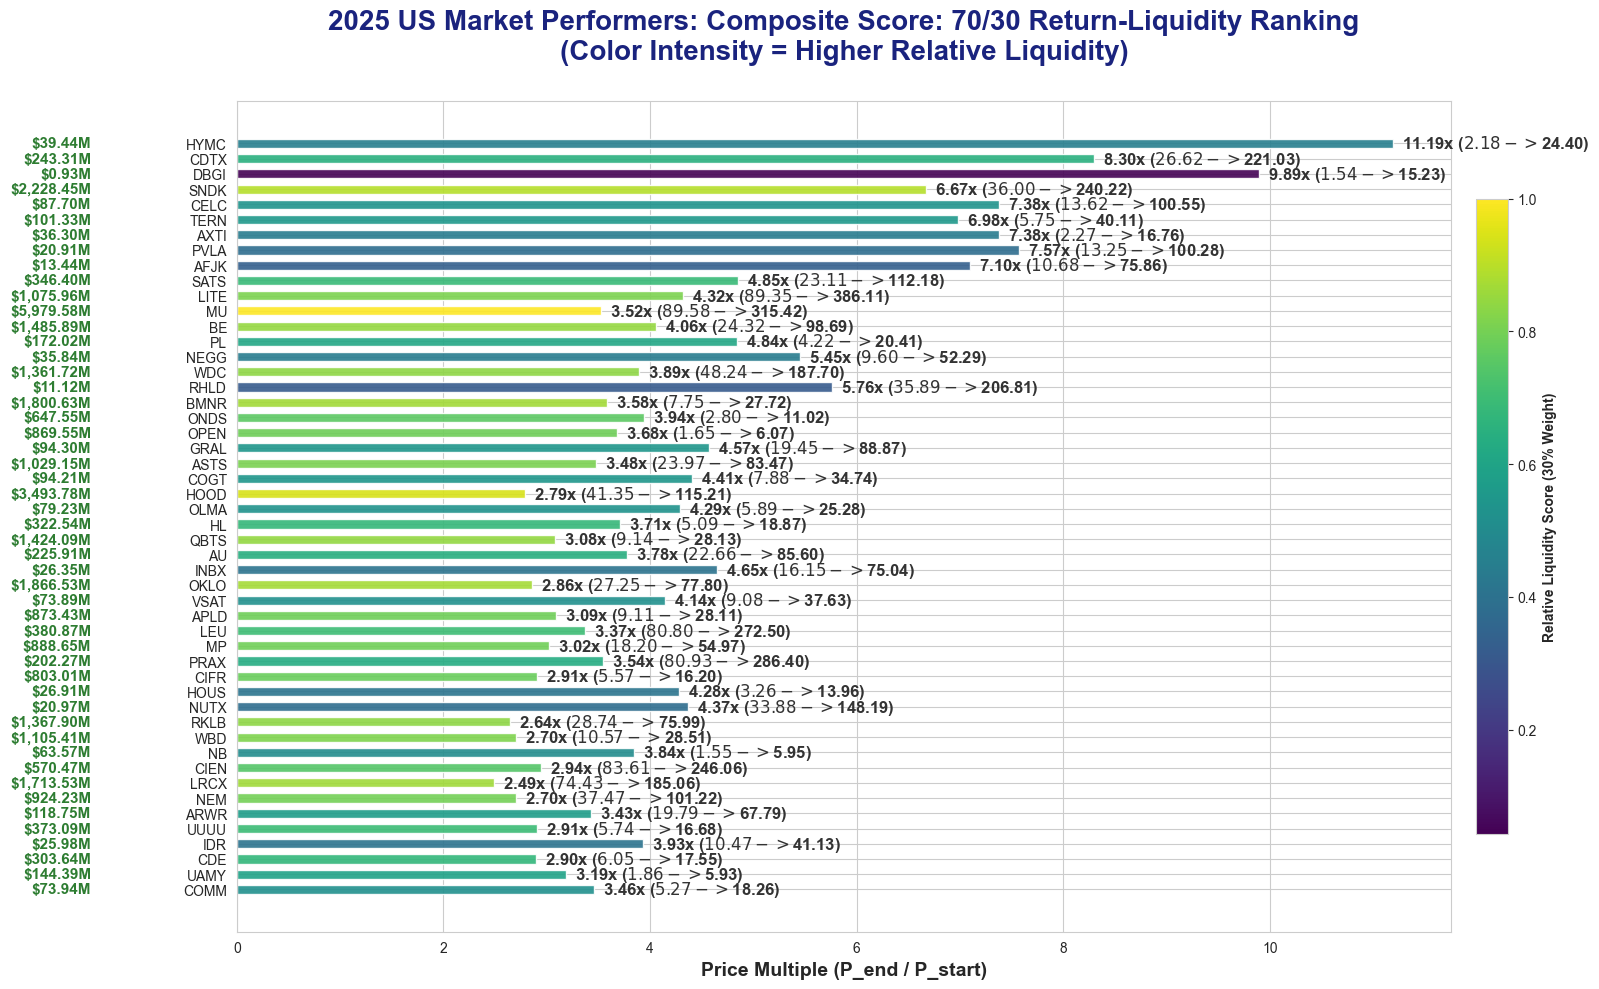

In [15]:
# Visualize top 20 by Composite Score (default)
visualize_winners(final_winners, sort_by='Composite_Score', top_n=50)


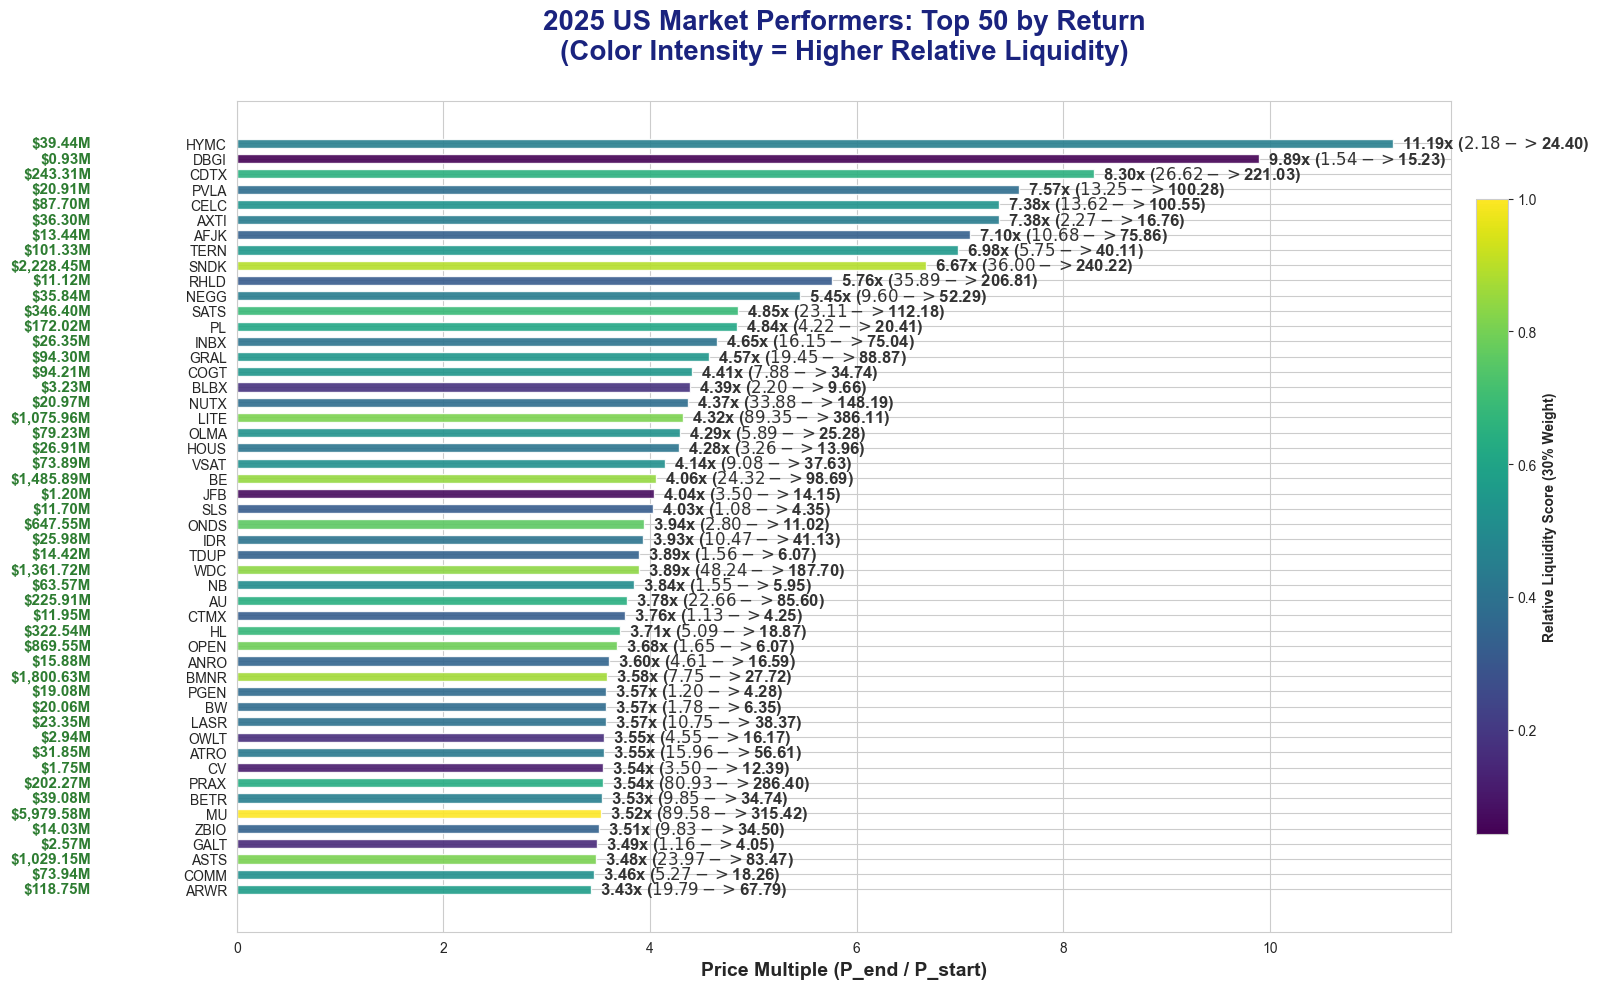

In [14]:
# Visualize top 20 by Return
visualize_winners(final_winners, sort_by='Return', top_n=50)


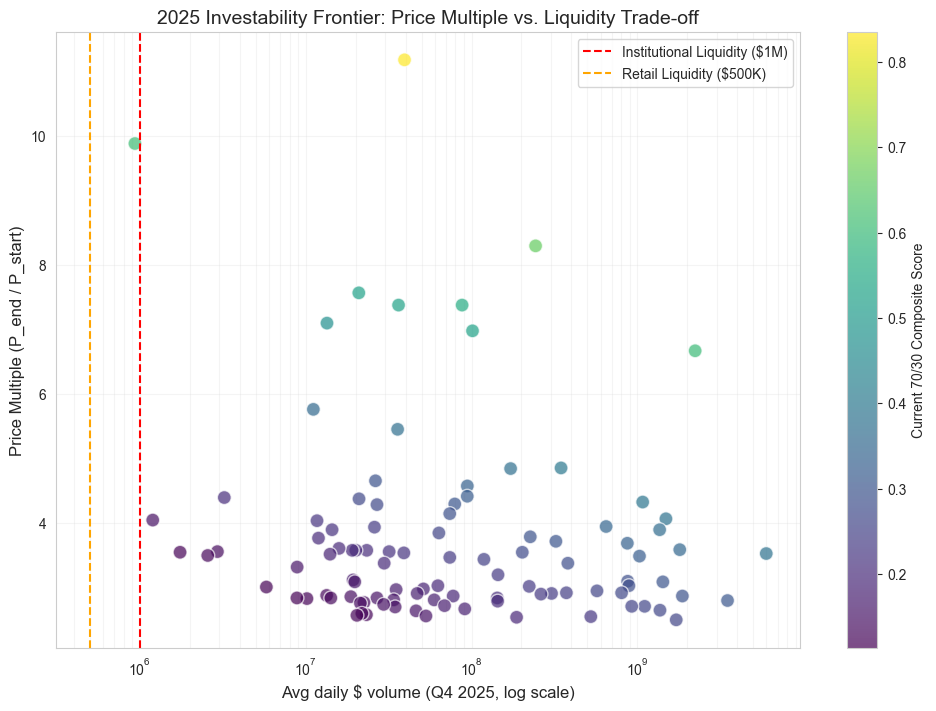

In [6]:

# Simple Trade-off Visualization for your Data Science pipeline
def plot_tradeoff_frontier(df):
    plt.figure(figsize=(12, 8))
    
    # Use Log scale for volume because it spans orders of magnitude
    x = df['Avg_Daily_Dollar_Vol']
    y = df['Return']  # Price multiple (P_end / P_start)
    
    # Color by your current Composite_Score to see the ranking bias
    scatter = plt.scatter(x, y, c=df['Composite_Score'], cmap='viridis', 
                          s=100, alpha=0.7, edgecolors='w')
    
    plt.xscale('log')
    plt.xlabel('Avg daily $ volume (Q4 2025, log scale)', fontsize=12)
    plt.ylabel('Price Multiple (P_end / P_start)', fontsize=12)
    plt.title('2025 Investability Frontier: Price Multiple vs. Liquidity Trade-off', fontsize=14)
    
    # Draw your threshold lines
    plt.axvline(x=1000000, color='red', linestyle='--', label='Institutional Liquidity ($1M)')
    plt.axvline(x=500000, color='orange', linestyle='--', label='Retail Liquidity ($500K)')
    
    cbar = plt.colorbar(scatter)
    cbar.set_label('Current 70/30 Composite Score')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

# Run this on your final_winners
plot_tradeoff_frontier(final_winners)

In [9]:
final_winners = pd.read_csv("top_100_2025_raw.csv")

final_winners.head(10)

,Symbol,Start_Price,End_Price,Type,IPO_Date,Company Name,Return,Avg_Daily_Dollar_Vol,Sector,MarketCap_B,ForwardPE,ProfitMargin,Return_Score,log_vol,Liquidity_Score,Composite_Score
0,HYMC,2.18,24.40,Established,Pre-2025,HYCROFT MINING HOLDING CORP,11.19,3.943519e+07,Basic Materials,2.2147,-148.1917,0.0000,1.0000,17.4902,0.4513,0.8354
1,CDTX,26.62,221.03,Established,Pre-2025,"Cidara Therapeutics, Inc.",8.30,2.433065e+08,Healthcare,6.9616,-30.7022,0.0000,0.6678,19.3098,0.6502,0.6625
2,DBGI,1.54,15.23,Established,Pre-2025,"Digital Brands Group, Inc.",9.89,9.346130e+05,Consumer Cyclical,0.1375,NaN,-1.6455,0.8506,13.7479,0.0424,0.6081
3,SNDK,36.00,240.22,IPO,2025-02-13,Sandisk Corp,6.67,2.228450e+09,Technology,52.6067,16.6986,-0.2236,0.4805,21.5246,0.8921,0.6040
4,CELC,13.62,100.55,Established,Pre-2025,Celcuity Inc.,7.38,8.769516e+07,Healthcare,4.8192,-23.0590,0.0000,0.5621,18.2894,0.5387,0.5550
5,TERN,5.75,40.11,Established,Pre-2025,"Terns Pharmaceuticals, Inc.",6.98,1.013312e+08,Healthcare,4.0200,-30.5175,0.0000,0.5161,18.4339,0.5544,0.5276
6,AXTI,2.27,16.76,Established,Pre-2025,AXT INC,7.38,3.630310e+07,Technology,1.3772,-6351.2500,-0.2522,0.5621,17.4074,0.4423,0.5261
7,PVLA,13.25,100.28,Established,Pre-2025,"PALVELLA THERAPEUTICS, INC.",7.57,2.091397e+07,Healthcare,1.1413,-23.8436,0.0000,0.5839,16.8559,0.3820,0.5233
8,AFJK,10.68,75.86,Established,Pre-2025,"Aimei Health Technology Co., Ltd.",7.10,1.344059e+07,Financial Services,0.3980,NaN,0.0000,0.5299,16.4138,0.3337,0.4710
9,SATS,23.11,112.18,Established,Pre-2025,EchoStar CORP,4.85,3.464021e+08,Communication Services,34.2544,-35.3408,-0.8536,0.2713,19.6631,0.6888,0.3965


In [10]:
from tqdm import tqdm
import numpy as np
import pandas as pd
import yfinance as yf

final_winners = pd.read_csv("top_100_2025_raw.csv")


def add_fundamentals(df_top_100: pd.DataFrame) -> pd.DataFrame:
    if "Symbol" not in df_top_100.columns:
        raise ValueError("df_top_100 must contain a 'Symbol' column")

    symbols = df_top_100["Symbol"].astype(str).tolist()
    rows = []

    for sym in tqdm(symbols):
        try:
            info = yf.Ticker(sym).info or {}

            market_cap = info.get("marketCap")
            roe = info.get("returnOnEquity")
            avg_vol = info.get("averageDailyVolume10Day")
            prev_close = info.get("previousClose")

            rows.append({
                "Symbol": sym,
                "MarketCap_B": round(market_cap / 1e9, 2) if isinstance(market_cap, (int, float)) else np.nan,
                "Daily_Vol_M": round((avg_vol * prev_close) / 1e6, 2)
                if isinstance(avg_vol, (int, float)) and isinstance(prev_close, (int, float))
                else np.nan,
                "ForwardPE": info.get("forwardPE", np.nan),
                "ProfitMargin": info.get("profitMargins", np.nan),
                "ROE": round(roe * 100, 1) if isinstance(roe, (int, float)) else np.nan,
                "DebtToEquity": info.get("debtToEquity", np.nan),
            })
        except Exception:
            rows.append({
                "Symbol": sym,
                "MarketCap_B": np.nan,
                "Daily_Vol_M": np.nan,
                "ForwardPE": np.nan,
                "ProfitMargin": np.nan,
                "ROE": np.nan,
                "DebtToEquity": np.nan,
            })

    df_fund = pd.DataFrame(rows)

    # Avoid ForwardPE_x/ForwardPE_y (and similar) if df_top_100 already has these columns.
    fund_cols = [c for c in df_fund.columns if c != "Symbol"]
    base = df_top_100.drop(columns=[c for c in fund_cols if c in df_top_100.columns], errors="ignore")
    out = base.merge(df_fund, on="Symbol", how="left")

    if "Composite_Score" in out.columns:
        out = out.sort_values("Composite_Score", ascending=False)

    return out.reset_index(drop=True)

df_top_100_final = add_fundamentals(final_winners)
df_top_100_final.to_csv('top_100_2025.csv')
df_top_100_final.head(10)


100%|██████████| 100/100 [00:51<00:00,  1.95it/s]


,Symbol,Start_Price,End_Price,Type,IPO_Date,Company Name,Return,Avg_Daily_Dollar_Vol,Sector,Return_Score,log_vol,Liquidity_Score,Composite_Score,MarketCap_B,Daily_Vol_M,ForwardPE,ProfitMargin,ROE,DebtToEquity
0,HYMC,2.18,24.40,Established,Pre-2025,HYCROFT MINING HOLDING CORP,11.19,3.943519e+07,Basic Materials,1.0000,17.4902,0.4513,0.8354,2.23,128.40,-149.160550,0.00000,-374.6,282.689
1,CDTX,26.62,221.03,Established,Pre-2025,"Cidara Therapeutics, Inc.",8.30,2.433065e+08,Healthcare,0.6678,19.3098,0.6502,0.6625,6.96,198.39,-30.702150,0.00000,-68.7,0.470
2,DBGI,1.54,15.23,Established,Pre-2025,"Digital Brands Group, Inc.",9.89,9.346130e+05,Consumer Cyclical,0.8506,13.7479,0.0424,0.6081,0.14,3.86,NaN,-1.64551,-162.8,40.003
3,SNDK,36.00,240.22,IPO,2025-02-13,Sandisk Corp,6.67,2.228450e+09,Technology,0.4805,21.5246,0.8921,0.6040,52.67,3648.55,16.717722,-0.22365,-16.2,16.661
4,CELC,13.62,100.55,Established,Pre-2025,Celcuity Inc.,7.38,8.769516e+07,Healthcare,0.5621,18.2894,0.5387,0.5550,4.81,65.79,-23.010315,0.00000,-122.0,273.886
5,TERN,5.75,40.11,Established,Pre-2025,"Terns Pharmaceuticals, Inc.",6.98,1.013312e+08,Healthcare,0.5161,18.4339,0.5544,0.5276,4.02,71.78,-30.509203,0.00000,-29.1,0.362
6,AXTI,2.27,16.76,Established,Pre-2025,AXT INC,7.38,3.630310e+07,Technology,0.5621,17.4074,0.4423,0.5261,1.37,206.56,-6317.500000,-0.25224,-9.9,28.569
7,PVLA,13.25,100.28,Established,Pre-2025,"PALVELLA THERAPEUTICS, INC.",7.57,2.091397e+07,Healthcare,0.5839,16.8559,0.3820,0.5233,1.17,23.34,-24.377537,0.00000,-301.2,41.417
8,AFJK,10.68,75.86,Established,Pre-2025,"Aimei Health Technology Co., Ltd.",7.10,1.344059e+07,Financial Services,0.5299,16.4138,0.3337,0.4710,0.40,16.79,NaN,0.00000,NaN,NaN
9,SATS,23.11,112.18,Established,Pre-2025,EchoStar CORP,4.85,3.464021e+08,Communication Services,0.2713,19.6631,0.6888,0.3965,34.19,456.68,-35.272488,-0.85364,-97.8,447.051


In [16]:
import pandas as pd
df_top_100 = pd.read_csv("top_100_2025.csv")

# Create the professional display
report_cols = ['Symbol', 'Company Name', 'Sector', 'Start_Price', 'End_Price', 'Return', 'MarketCap_B', 'Daily_Vol_M', 'ForwardPE', 'ROE', 'DebtToEquity', 'Composite_Score']

missing = [c for c in report_cols if c not in df_top_100.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}. Re-run the add_fundamentals cell above.")

styler = (
    df_top_100[report_cols].head(50).style
    .format({
        'Start_Price': '${:.2f}',  
        'End_Price': '${:.2f}',
        'Return': '{:.2f}x',
        'MarketCap_B': '${:.1f}B',
        'Daily_Vol_M': '${:.1f}M',
        'ForwardPE': '{:.1f}',
        'ROE': '{:.1f}%',
        'DebtToEquity': '{:.2f}',
        'Composite_Score': '{:.2f}'
    }, na_rep='n/a')
    .background_gradient(subset=['Return', 'Composite_Score'], cmap='Greens')
    .set_properties(**{'text-align': 'center'})
)

styler


,Symbol,Company Name,Sector,Start_Price,End_Price,Return,MarketCap_B,Daily_Vol_M,ForwardPE,ROE,DebtToEquity,Composite_Score
0,HYMC,HYCROFT MINING HOLDING CORP,Basic Materials,$2.18,$24.40,11.19x,$2.2B,$128.4M,-149.2,-374.6%,282.69,0.84
1,CDTX,"Cidara Therapeutics, Inc.",Healthcare,$26.62,$221.03,8.30x,$7.0B,$198.4M,-30.7,-68.7%,0.47,0.66
2,DBGI,"Digital Brands Group, Inc.",Consumer Cyclical,$1.54,$15.23,9.89x,$0.1B,$3.9M,n/a,-162.8%,40.00,0.61
3,SNDK,Sandisk Corp,Technology,$36.00,$240.22,6.67x,$52.7B,$3648.6M,16.7,-16.2%,16.66,0.60
4,CELC,Celcuity Inc.,Healthcare,$13.62,$100.55,7.38x,$4.8B,$65.8M,-23.0,-122.0%,273.89,0.56
5,TERN,"Terns Pharmaceuticals, Inc.",Healthcare,$5.75,$40.11,6.98x,$4.0B,$71.8M,-30.5,-29.1%,0.36,0.53
6,AXTI,AXT INC,Technology,$2.27,$16.76,7.38x,$1.4B,$206.6M,-6317.5,-9.9%,28.57,0.53
7,PVLA,"PALVELLA THERAPEUTICS, INC.",Healthcare,$13.25,$100.28,7.57x,$1.2B,$23.3M,-24.4,-301.2%,41.42,0.52
8,AFJK,"Aimei Health Technology Co., Ltd.",Financial Services,$10.68,$75.86,7.10x,$0.4B,$16.8M,n/a,n/a,n/a,0.47
9,SATS,EchoStar CORP,Communication Services,$23.11,$112.18,4.85x,$34.2B,$456.7M,-35.3,-97.8%,447.05,0.40


In [13]:
import pandas as pd
import sys
import subprocess
import importlib.util

# Ensure XlsxWriter is installed in *this* notebook kernel environment
if importlib.util.find_spec("xlsxwriter") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "XlsxWriter"])

report_cols = [
    'Symbol', 'Company Name', 'Sector', 'Start_Price', 'End_Price', 'Return', 'MarketCap_B', 'Daily_Vol_M',
    'ForwardPE', 'ROE', 'DebtToEquity', 'Composite_Score'
]

df_report = df_top_100_final[report_cols].head(100).copy()

# Insert index / rank column
df_report.insert(0, "Rank", range(1, len(df_report) + 1))

# Round for readability in the saved file
round_map = {
    "Start_Price": 2,
    "End_Price": 2,
    "Return": 2,
    "MarketCap_B": 2,
    "Daily_Vol_M": 1,
    "ForwardPE": 1,
    "ROE": 1,
    "DebtToEquity": 2,
    "Composite_Score": 2,
}
for c, d in round_map.items():
    if c in df_report.columns:
        df_report[c] = pd.to_numeric(df_report[c], errors="coerce").round(d)

# Show missing fundamentals as text (no heatmap)
na_cols = ["ForwardPE", "ROE", "DebtToEquity", "MarketCap_B", "Daily_Vol_M"]
for c in na_cols:
    if c in df_report.columns:
        df_report[c] = df_report[c].where(pd.notna(df_report[c]), "n/a")

out_xlsx = "Best of 2025.xlsx"

with pd.ExcelWriter(out_xlsx, engine="xlsxwriter") as writer:
    sheet_name = "Audit"
    df_report.to_excel(writer, sheet_name=sheet_name, index=False)

    workbook = writer.book
    ws = writer.sheets[sheet_name]

    # Freeze header row
    ws.freeze_panes(1, 0)

    # Header formatting
    header_fmt = workbook.add_format({
        "bold": True,
        "font_color": "#FFFFFF",
        "bg_color": "#1F4E79",
        "align": "center",
        "valign": "vcenter",
        "border": 1,
    })

    # Cell formats
    text_left = workbook.add_format({"align": "left", "valign": "vcenter"})
    text_center = workbook.add_format({"align": "center", "valign": "vcenter"})
    int_center = workbook.add_format({"num_format": "0", "align": "center", "valign": "vcenter"})

    money2 = workbook.add_format({"num_format": "$#,##0.00", "align": "right", "valign": "vcenter"})
    num1 = workbook.add_format({"num_format": "0.0", "align": "right", "valign": "vcenter"})
    num2 = workbook.add_format({"num_format": "0.00", "align": "right", "valign": "vcenter"})
    num2x = workbook.add_format({"num_format": '0.00"x"', "align": "right", "valign": "vcenter"})

    for col_idx, col_name in enumerate(df_report.columns):
        ws.write(0, col_idx, col_name, header_fmt)

    # Column widths
    widths = {
        "Rank": 6,
        "Symbol": 8,
        "Company Name": 34,
        "Start_Price": 11,
        "End_Price": 11,
        "Return": 10,
        "MarketCap_B": 12,
        "Daily_Vol_M": 12,
        "ForwardPE": 11,
        "ROE": 9,
        "DebtToEquity": 12,
        "Composite_Score": 16,
    }

    # Apply alignment + formats per column
    col_to_fmt = {
        "Rank": int_center,
        "Symbol": text_center,
        "Company Name": text_left,
        "Start_Price": money2,
        "End_Price": money2,
        "Return": num2x,
        "MarketCap_B": num2,
        "Daily_Vol_M": num1,
        "ForwardPE": num1,
        "ROE": num1,
        "DebtToEquity": num2,
        "Composite_Score": num2,
    }

    for col_idx, col_name in enumerate(df_report.columns):
        ws.set_column(col_idx, col_idx, widths.get(col_name, 12), col_to_fmt.get(col_name))

out_xlsx


'Best of 2025.xlsx'